# CFReT Phenotypic Compound Scores Plot

This notebook visualizes the on-morphological and off-morphological phenotypic scores for CFReT compounds. Each point represents a treatment condition scored against the **healthy DMSO** reference profile. The quadrant lines at 0.5 delineate regions of high/low on-signature and high/low off-signature activity, enabling rapid identification of compounds with desired phenotypic profiles.

In [1]:
suppressPackageStartupMessages({
  library(dplyr)
  library(ggplot2)
  library(ggrepel)
  library(IRdisplay)
})

## Load Data and Set Paths

In [2]:
# Input and output paths
scores_path <- file.path("../results/phenotypic_scores/cfret_pilot_phenotypic_scores.csv")

if (!file.exists(scores_path)) {
  stop(paste("File not found:", scores_path))
}

output_dir <- file.path("./figures")
if (!dir.exists(output_dir)) {
  dir.create(output_dir, showWarnings = FALSE, recursive = TRUE)
}

# Load data
scores_df <- read.csv(scores_path)
head(scores_df)

,rank,ref_profile,treatment,on_score,off_score
,<int>,<chr>,<chr>,<dbl>,<dbl>
1,1,healthy_DMSO,healthy_TGFRi,0.6814266,0.1470588
2,2,healthy_DMSO,failing_TGFRi,0.9041957,0.2647059
3,3,healthy_DMSO,failing_DMSO,1.0000000,0.0000000


## Generate Scatter Plot

Each point is a treatment scored against the **healthy DMSO** reference. Because a lower on-score reflects greater reversal toward the healthy morphological state, the quadrant lines at 0.5 map to:

- **Bottom-left** (on < 0.5, off < 0.5): Strong reversal toward healthy with minimal off-target effects — **ideal**.
- **Bottom-right** (on < 0.5, off ≥ 0.5): Reversal toward reference but with substantial off-target perturbation.
- **Top-left** (on ≥ 0.5, off < 0.5): Weak or no reversal with minimal off-target effects — compound has little impact.
- **Top-right** (on ≥ 0.5, off ≥ 0.5): No reversal and high off-target activity — least desirable.

Saved: ./figures/cfret_phenotypic_scores_scatter.png 


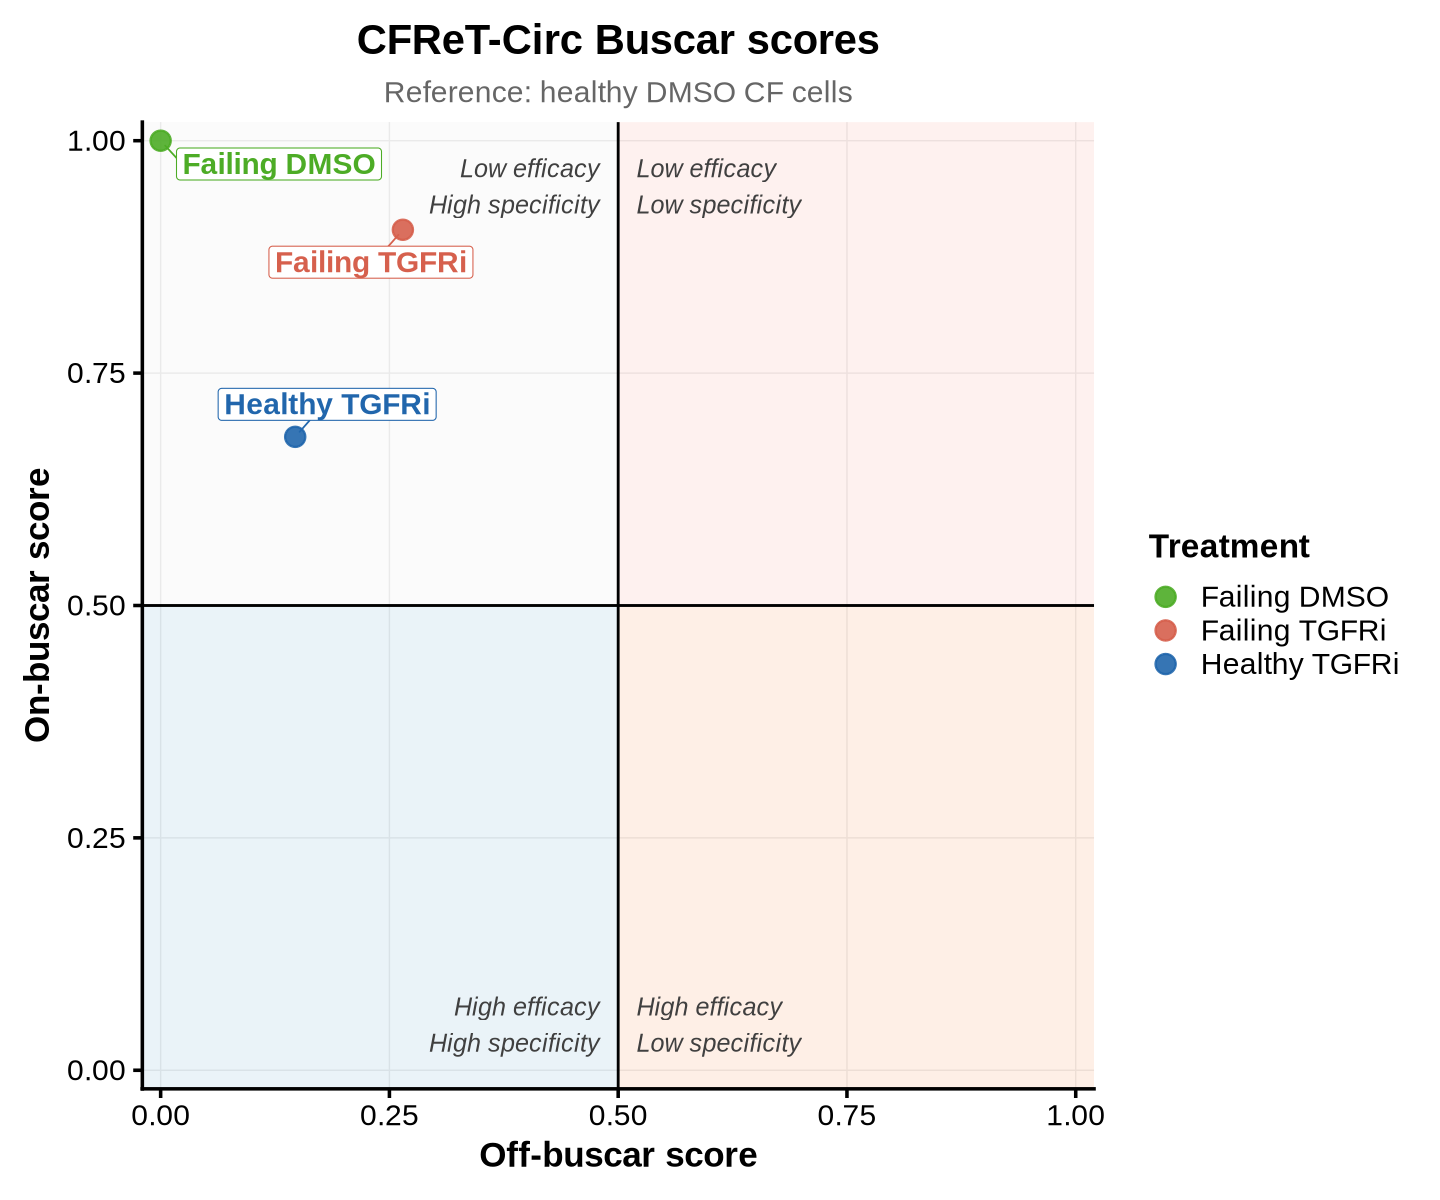

In [5]:
# Clean treatment labels for display
scores_df <- scores_df %>%
  mutate(
    label = gsub("_", " ", treatment),
    label = tools::toTitleCase(label)
  )

# Assign distinct colors per treatment
treatment_colors <- c(
  "healthy_TGFRi" = "#2166AC",  # blue
  "failing_TGFRi" = "#D6604D",  # orange-red
  "failing_DMSO"  = "#4DAC26"   # green
)

# Plot dimensions
width  <- 12
height <- 10
options(repr.plot.width = width, repr.plot.height = height)

scores_plot <- ggplot(scores_df, aes(x = off_score, y = on_score, color = treatment, label = label)) +

  # Quadrant shading — bottom-left is ideal (strong reversal, low off-target)
  annotate("rect", xmin = -Inf, xmax = 0.5, ymin = -Inf, ymax = 0.5, fill = "#d1e5f0", alpha = 0.45) +  # bottom-left: ideal
  annotate("rect", xmin = 0.5,  xmax = Inf,  ymin = -Inf, ymax = 0.5, fill = "#fddbc7", alpha = 0.45) +  # bottom-right: reversal + off-target
  annotate("rect", xmin = -Inf, xmax = 0.5,  ymin = 0.5,  ymax = Inf,  fill = "#f7f7f7", alpha = 0.45) +  # top-left: weak reversal
  annotate("rect", xmin = 0.5,  xmax = Inf,  ymin = 0.5,  ymax = Inf,  fill = "#fde0dc", alpha = 0.45) +  # top-right: worst

  # Quadrant lines at 0.5
  geom_vline(xintercept = 0.5, color = "black", linewidth = 0.8) +
  geom_hline(yintercept = 0.5, color = "black", linewidth = 0.8) +

  # Quadrant annotation labels — all left-aligned within their quadrant
  # Left quadrants: text on the right side (near center line)
  annotate("text", x = 0.48, y = 0.02, label = "High efficacy\nHigh specificity",
           hjust = 1, vjust = 0, size = 5.3, fontface = "italic", color = "gray25") +
  annotate("text", x = 0.48, y = 0.98, label = "Low efficacy\nHigh specificity",
           hjust = 1, vjust = 1, size = 5.3, fontface = "italic", color = "gray25") +
  # Right quadrants: text on the left side (near center line)
  annotate("text", x = 0.52, y = 0.02, label = "High efficacy\nLow specificity",
           hjust = 0, vjust = 0, size = 5.3, fontface = "italic", color = "gray25") +
  annotate("text", x = 0.52, y = 0.98, label = "Low efficacy\nLow specificity",
           hjust = 0, vjust = 1, size = 5.3, fontface = "italic", color = "gray25") +

  # Data points
  geom_point(size = 5, alpha = 0.9) +

  # Repelled text labels
  geom_label_repel(
    size          = 6.3,
    fontface      = "bold",
    box.padding   = 0.6,
    point.padding = 0.4,
    label.size    = 0.3,
    show.legend   = FALSE,
    seed          = 42
  ) +

  # Scales
  scale_color_manual(
    values = treatment_colors,
    labels = c(
      "failing_DMSO"  = "Failing DMSO",
      "failing_TGFRi" = "Failing TGFRi",
      "healthy_TGFRi" = "Healthy TGFRi"
    )
  ) +
  scale_x_continuous(limits = c(0, 1), breaks = seq(0, 1, 0.25), expand = expansion(mult = 0.02)) +
  scale_y_continuous(limits = c(0, 1), breaks = seq(0, 1, 0.25), expand = expansion(mult = 0.02)) +

  # Labels
  labs(
    x        = "Off-buscar score",
    y        = "On-buscar score",
    title    = "CFReT-Circ Buscar scores",
    subtitle = "Reference: healthy DMSO CF cells",
    color    = "Treatment"
  ) +

  # Publication theme — all text elements 40% larger than baseline
  theme_classic(base_size = 22) +
  theme(
    plot.title       = element_text(hjust = 0.5, face = "bold", size = 25),
    plot.subtitle    = element_text(hjust = 0.5, color = "gray40", size = 18, margin = margin(b = 8)),
    axis.title       = element_text(face = "bold", size = 21),
    axis.text        = element_text(size = 18),
    legend.position  = "right",
    legend.title     = element_text(face = "bold", size = 20),
    legend.text      = element_text(size = 18),
    legend.key.size  = unit(1.4, "lines"),
    panel.grid.major = element_line(color = "gray88", linewidth = 0.4),
    panel.grid.minor = element_blank(),
    plot.margin      = margin(15, 15, 15, 15)
  )

# Save
output_path <- file.path(output_dir, "cfret_phenotypic_scores_scatter.png")
ggsave(output_path, scores_plot, width = width, height = height, dpi = 300, bg = "white")
cat("Saved:", output_path, "\n")

scores_plot